In [1]:
from datascience import *
%matplotlib inline
path_data = 'data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import math
import numpy as np
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 상관관계 (Correlation)

이 섹션에서는 산점도가 직선 주위에 얼마나 촘촘하게 모여 있는지에 대한 척도를 개발할 것입니다. 공식적으로는 이를 *선형 연관성(linear association)* 측정이라고 합니다.

In [ ]:
x = np.random.normal(0, 1, 1000)
x

array([  7.67081312e-01,   6.52485867e-01,  -1.20712972e-01,
         3.40696236e-01,  -1.78678101e+00,  -4.59493333e-01,
        -1.24012680e+00,   1.22895988e+00,  -3.73637481e-01,
        -4.65346577e-01,  -8.64254064e-01,   1.98564451e+00,
         1.72679337e+00,   1.36122101e+00,  -3.47027875e-02,
        -5.83175739e-01,  -5.04518078e-01,  -7.61836309e-01,
         1.62977284e+00,  -3.80951403e-01,   4.98224199e-01,
        -4.65368210e-01,  -6.81612209e-01,   1.41750262e+00,
        -2.04594218e-01,  -1.45439270e+00,  -1.76173507e+00,
        -8.83072341e-01,   3.49479910e-01,  -3.50198194e-02,
        -1.95121400e+00,  -1.80221165e-01,  -5.64292940e-02,
        -3.08032280e-01,  -7.60083517e-01,  -1.21888021e+00,
         4.51657874e-01,   4.78817668e-01,  -5.44627251e-01,
         1.98932190e+00,   7.54171452e-01,   1.70689494e+00,
        -1.99812854e+00,  -1.52149512e+00,  -1.04618369e-01,
        -8.14195215e-02,   1.28926170e+00,  -9.10729307e-01,
        -2.63797509e-01,

In [ ]:
def r_scatter(r):
    plots.figure(figsize=(5,5))
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plots.scatter(x, y)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)

`hybrid` 테이블에는 1997년부터 2013년까지 미국에서 판매된 하이브리드 승용차에 대한 데이터가 포함되어 있습니다. 데이터는 플로리다 대학교의 [래리 위너(Larry Winner) 교수](http://www.stat.ufl.edu/%7Ewinner/)의 온라인 데이터 아카이브에서 가져왔습니다. 열:

- `vehicle`: 자동차 모델
- `year`: 제조 연도
- `msrp`: 제조업체 권장 소비자 가격(2013년 달러 기준)
- `acceleration`: 가속율(초당 km/h)
- `mpg`: 연비(갤런당 마일)
- `class`: 모델의 등급

In [ ]:
hybrid = Table.read_table(path_data + 'hybrid.csv')

In [ ]:
hybrid

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact
Insight,2000,18936.4,9.52,53,Two Seater
Civic (1st Gen),2001,25833.4,7.04,47.04,Compact
Insight,2001,19036.7,9.52,53,Two Seater
Insight,2002,19137,9.71,53,Two Seater
Alphard,2003,38084.8,8.33,40.46,Minivan
Insight,2003,19137,9.52,53,Two Seater
Civic,2003,14071.9,8.62,41,Compact


아래 그래프는 `msrp` *대* `acceleration`의 산점도입니다. 즉, `msrp`가 수직축에, `acceleration`이 수평축에 표시됩니다.

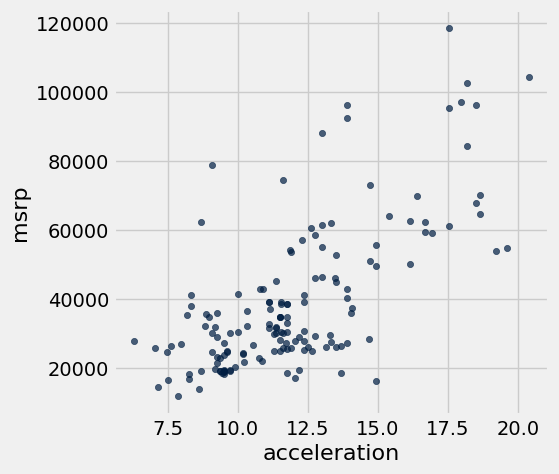

In [ ]:
hybrid.scatter('acceleration', 'msrp')

양의 연관성에 주목하십시오. 점들의 산포는 위쪽으로 기울어져 있어 가속력이 더 좋은 차들이 평균적으로 가격이 더 비싼 경향이 있음을 나타냅니다; 반대로 가격이 더 비싼 차들이 평균적으로 가속력이 더 좋은 경향이 있었습니다.

MSRP 대 마일리지의 산점도는 음의 연관성을 보여줍니다. 마일리지가 더 높은 하이브리드 자동차는 평균적으로 가격이 더 낮은 경향이 있었습니다. 가속이 빠른 차들이 연비가 낮고 마일리지가 낮은 경향이 있다는 점을 고려할 때까지는 놀라워 보일 수 있습니다. 이전 산점도에서 보여주었듯이, 그 차들은 또한 가격이 더 비싼 경향이 있는 차들이었습니다.

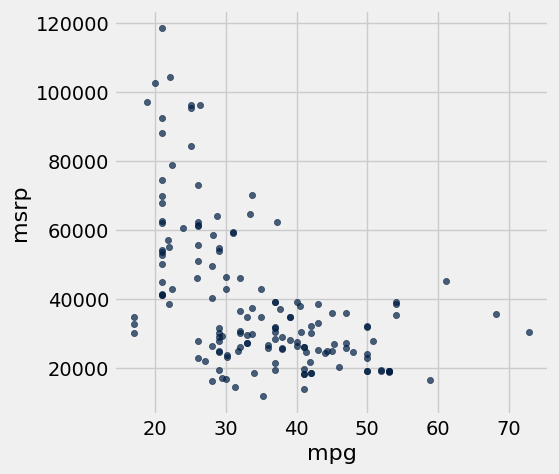

In [ ]:
hybrid.scatter('mpg', 'msrp')

음의 연관성과 함께 가격 대 효율성 산점도는 두 변수 사이의 비선형 관계를 보여줍니다. 점들이 직선이 아닌 곡선 주위에 모여 있는 것처럼 보입니다.

그러나 데이터를 SUV 등급으로만 제한하면 가격과 효율성 사이의 연관성은 여전히 음수이지만 관계는 더 선형적으로 보입니다. SUV의 가격과 가속력 사이의 관계 또한 선형 추세를 보여주지만 기울기는 양수입니다.

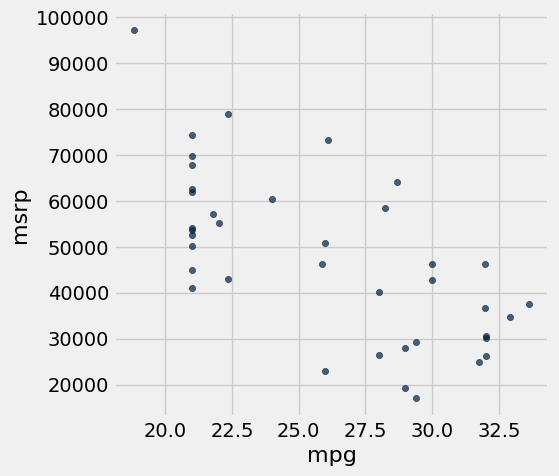

In [ ]:
suv = hybrid.where('class', 'SUV')
suv.scatter('mpg', 'msrp')

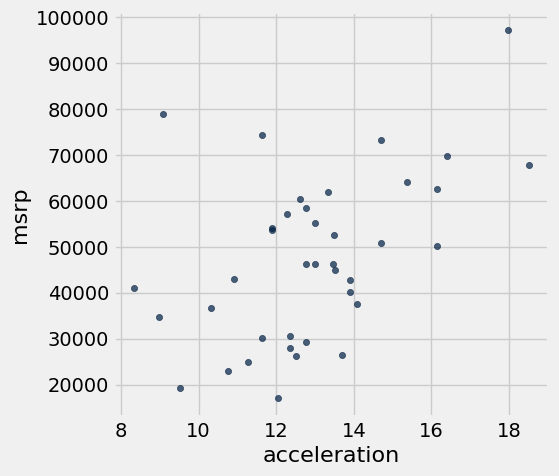

In [ ]:
suv.scatter('acceleration', 'msrp')

변수가 측정된 단위에 주의를 기울이지 않더라도 산점도의 일반적인 방향과 모양에서 유용한 정보를 얻을 수 있다는 것을 눈치챘을 것입니다.

실제로 모든 변수를 표준 단위로 플롯해도 플롯은 똑같이 보일 것입니다. 이것은 두 산점도의 선형성 정도를 비교할 수 있는 방법을 제공합니다.

이전 섹션에서 숫자 배열을 표준 단위로 변환하기 위해 `standard_units` 함수를 정의했음을 상기하십시오.

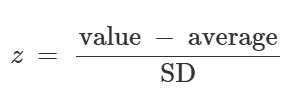

In [ ]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)

이 함수를 사용하여 모든 변수를 표준 단위로 측정하여 SUV에 대한 두 개의 산점도를 다시 그릴 수 있습니다.

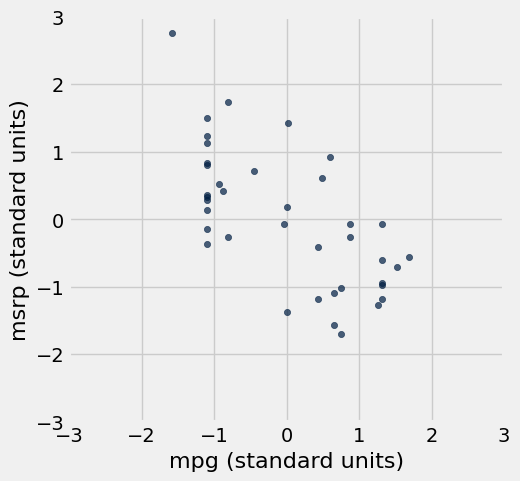

In [ ]:
Table().with_columns(
    'mpg (standard units)',  standard_units(suv.column('mpg')),
    'msrp (standard units)', standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

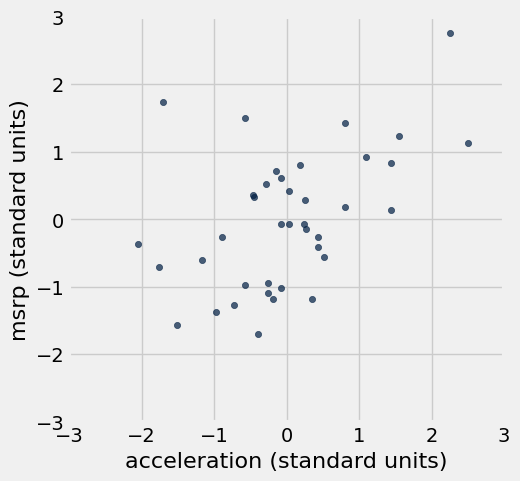

In [ ]:
Table().with_columns(
    'acceleration (standard units)', standard_units(suv.column('acceleration')),
    'msrp (standard units)',         standard_units(suv.column('msrp'))
).scatter(0, 1)
plots.xlim(-3, 3)
plots.ylim(-3, 3);

이 그림들에서 보는 연관성은 이전에 본 것과 동일합니다. 또한 두 산점도가 이제 정확히 동일한 척도로 그려졌기 때문에 두 번째 다이어그램의 선형 관계가 첫 번째보다 약간 더 흐릿하다는 것을 알 수 있습니다.

이제 표준 단위를 사용하여 우리가 본 연관성의 종류를 정량화하는 척도를 정의하겠습니다.

## 상관 계수 (The correlation coefficient)

*상관 계수*는 두 변수 사이의 선형 관계의 강도를 측정합니다. 그래픽적으로는 산점도가 직선 주위에 얼마나 모여 있는지를 측정합니다.

*상관 계수*라는 용어는 말하기 쉽지 않으므로 일반적으로 *상관관계(correlation)*로 줄여서 부르며 $r$로 표기합니다.

다음은 시뮬레이션을 통해 관찰할 $r$에 대한 몇 가지 수학적 사실입니다.

- 상관 계수 $r$은 $-1$과 1 사이의 숫자입니다.
- $r$은 산점도가 직선 주위에 모여 있는 정도를 측정합니다.
- 산점도가 위쪽으로 기울어진 완벽한 직선이면 $r = 1$이고, 아래쪽으로 기울어진 완벽한 직선이면 $r = -1$입니다.

``r_scatter`` 함수는 $r$ 값을 인수로 받아 $r$에 매우 가까운 상관관계를 가진 산점도를 시뮬레이션합니다. 시뮬레이션의 무작위성 때문에 상관관계가 $r$과 정확히 같을 것으로 예상되지는 않습니다.

서로 다른 $r$ 값을 인수로 하여 ``r_scatter``를 몇 번 호출하고 산점도가 어떻게 변하는지 확인해 보십시오.

$r=1$일 때 산점도는 완벽하게 선형이며 위쪽으로 기울어집니다. $r=-1$일 때 산점도는 완벽하게 선형이며 아래쪽으로 기울어집니다. $r=0$일 때 산점도는 수평축 주위의 형태 없는 구름 모양이며, 변수들은 *상관관계가 없다(uncorrelated)*고 말합니다.

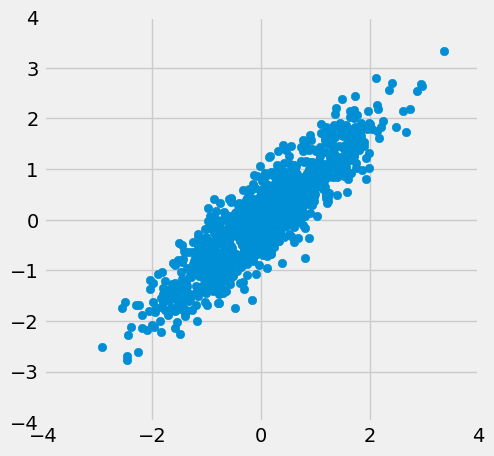

In [ ]:
r_scatter(0.9)

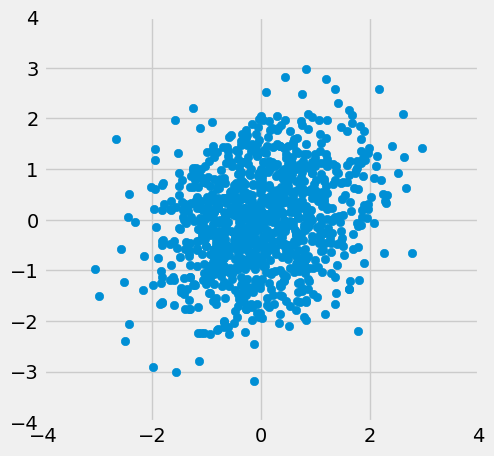

In [ ]:
r_scatter(0.25)

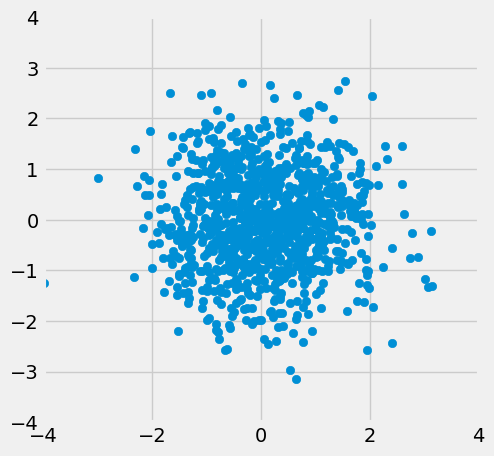

In [ ]:
r_scatter(0)

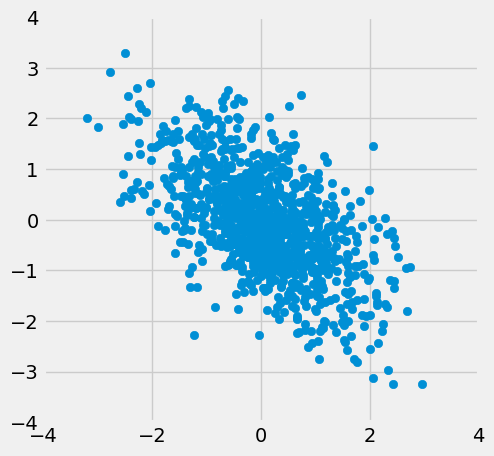

In [ ]:
r_scatter(-0.55)

## $r$ 계산하기

$r$에 대한 공식은 지금까지의 관찰에서 명확하지 않습니다. 그것은 이 수업의 범위를 벗어나는 수학적 기초를 가지고 있습니다. 그러나 보시다시피 계산은 간단하며 $r$의 몇 가지 속성을 이해하는 데 도움이 됩니다.

**$r$ 공식**:

**$r$은 두 변수가 모두 표준 단위로 측정되었을 때 두 변수의 곱의 평균입니다.**

계산 단계는 다음과 같습니다. 간단한 $x$와 $y$ 값 테이블에 이 단계를 적용해 보겠습니다.

In [ ]:
x = np.arange(1, 7, 1)
y = make_array(2, 3, 1, 5, 2, 7)
t = Table().with_columns(
        'x', x,
        'y', y
    )
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


산점도를 바탕으로 우리는 $r$이 양수이지만 1과는 같지 않을 것으로 예상합니다.

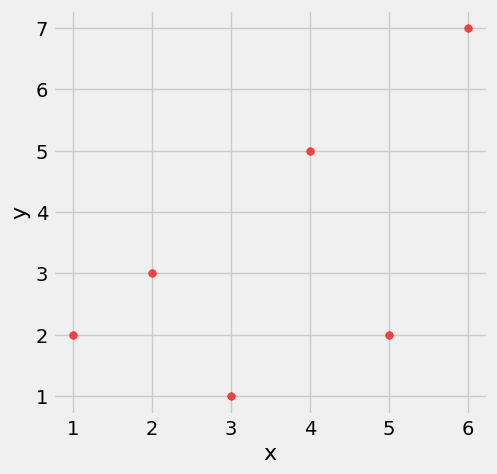

In [ ]:
t.scatter(0, 1, s=30, color='red')

**1단계.** 각 변수를 표준 단위로 변환합니다.

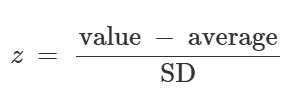

In [ ]:
t_su = t.with_columns(
        'x (standard units)', standard_units(x),
        'y (standard units)', standard_units(y)
    )
t_su

x,y,x (standard units),y (standard units)
1,2,-1.46385,-0.648886
2,3,-0.87831,-0.162221
3,1,-0.29277,-1.13555
4,5,0.29277,0.811107
5,2,0.87831,-0.648886
6,7,1.46385,1.78444


**2단계.** 표준 단위의 각 쌍을 곱합니다.

In [ ]:
t_product = t_su.with_column('product of standard units', t_su.column(2) * t_su.column(3))
t_product

x,y,x (standard units),y (standard units),product of standard units
1,2,-1.46385,-0.648886,0.949871
2,3,-0.87831,-0.162221,0.142481
3,1,-0.29277,-1.13555,0.332455
4,5,0.29277,0.811107,0.237468
5,2,0.87831,-0.648886,-0.569923
6,7,1.46385,1.78444,2.61215


**3단계.** $r$은 2단계에서 계산된 곱들의 평균입니다.

In [ ]:
# r is the average of the products of standard units

r = np.mean(t_product.column(4))
r

0.61741639718977093

예상대로 $r$은 양수이지만 1과 같지는 않습니다.

## $r$의 속성

계산 결과는 다음을 보여줍니다:

- $r$은 순수한 숫자입니다. 단위가 없습니다. 이는 $r$이 표준 단위를 기반으로 하기 때문입니다.
- $r$은 어느 축의 단위를 변경해도 영향을 받지 않습니다. 이 또한 $r$이 표준 단위를 기반으로 하기 때문입니다.
- $r$은 축을 바꿔도 영향을 받지 않습니다. 대수적으로 이는 표준 단위의 곱이 어떤 변수를 $x$라 하고 어떤 변수를 $y$라 하는지에 의존하지 않기 때문입니다. 기하학적으로 축을 바꾸면 산점도가 $y=x$ 선을 기준으로 반사되지만 모여 있는 정도나 연관성의 부호는 바뀌지 않습니다.

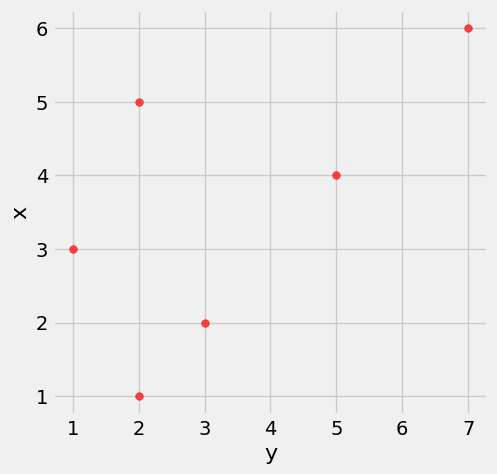

In [ ]:
t.scatter('y', 'x', s=30, color='red')

## `correlation` 함수
상관관계를 반복적으로 계산할 것이므로 위에서 설명한 모든 단계를 수행하여 계산하는 함수를 정의하는 것이 도움이 될 것입니다. 테이블과 테이블의 두 열 레이블을 받는 ``correlation`` 함수를 정의해 봅시다. 이 함수는 표준 단위로 된 해당 열 값들의 곱의 평균인 $r$을 반환합니다.

In [ ]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

``t``의 ``x``와 ``y`` 열에 대해 이 함수를 호출해 봅시다. 이 함수는 $r$ 공식을 직접 적용하여 얻은 것과 동일한 $x$와 $y$ 사이의 상관관계 답을 반환합니다.

In [ ]:
correlation(t, 'x', 'y')

0.61741639718977093

우리가 알아차렸듯이 변수가 지정되는 순서는 중요하지 않습니다.

In [ ]:
correlation(t, 'y', 'x')

0.61741639718977093

``suv`` 테이블의 열에 대해 ``correlation``을 호출하면 가격과 마일리지 사이의 상관관계뿐만 아니라 가격과 가속력 사이의 상관관계도 얻을 수 있습니다.

In [ ]:
correlation(suv, 'mpg', 'msrp')

-0.6667143635709919

In [ ]:
correlation(suv, 'acceleration', 'msrp')

0.48699799279959155

이 값들은 우리가 관찰한 것을 확인시켜 줍니다:

- 가격과 효율성 사이에는 음의 연관성이 있는 반면, 가격과 가속력 사이의 연관성은 양수입니다.
- 가격과 가속력 사이의 선형 관계는 가격과 마일리지 사이(상관관계 약 -0.67)보다 약간 더 약합니다(상관관계 약 0.5).

상관관계는 간단하고 강력한 개념이지만 때때로 오용되기도 합니다. $r$을 사용하기 전에 상관관계가 무엇을 측정하고 무엇을 측정하지 않는지 아는 것이 중요합니다.

## 연관성은 인과관계가 아닙니다

상관관계는 연관성만을 측정합니다. 상관관계가 인과관계를 의미하지는 않습니다. 학군의 어린이 몸무게와 수학 능력 사이의 상관관계가 양수일 수 있지만, 이것이 수학을 하는 것이 아이들을 더 무겁게 만들거나 체중을 늘리는 것이 아이들의 수학 능력을 향상시킨다는 것을 의미하지는 않습니다. 나이는 교란 변수입니다: 나이 든 아이들이 평균적으로 더 어린 아이들보다 더 무겁고 수학을 더 잘합니다.

## 상관관계는 *선형* 연관성을 측정합니다
상관관계는 단 하나의 종류의 연관성, 즉 선형 연관성만 측정합니다. 강한 비선형 연관성을 가진 변수들은 상관관계가 매우 낮을 수 있습니다. 다음은 완벽한 2차 관계 $y = x^2$를 갖지만 상관관계가 0인 변수의 예입니다.

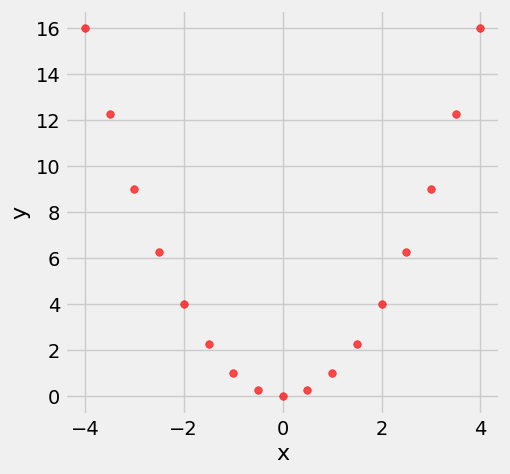

In [ ]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
        'x', new_x,
        'y', new_x**2
    )
nonlinear.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(nonlinear, 'x', 'y')

0.0

## 상관관계는 이상치(Outliers)의 영향을 받습니다
이상치는 상관관계에 큰 영향을 미칠 수 있습니다. 다음은 $r$이 1인 산점도가 단 하나의 이상치 점을 추가함으로써 $r$이 0인 플롯으로 바뀌는 예입니다.

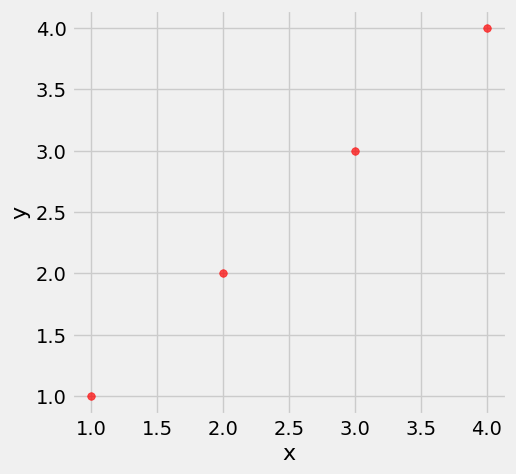

In [ ]:
line = Table().with_columns(
        'x', make_array(1, 2, 3, 4),
        'y', make_array(1, 2, 3, 4)
    )
line.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(line, 'x', 'y')

1.0

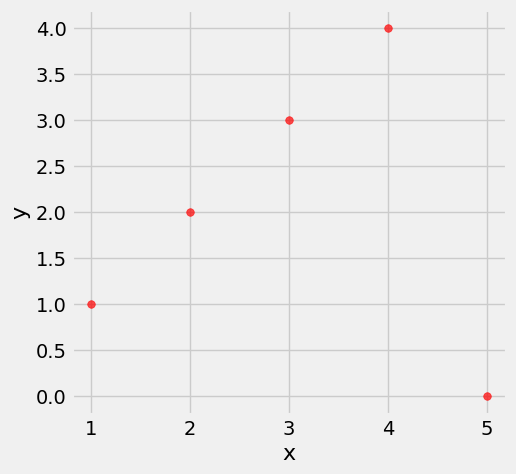

In [ ]:
outlier = Table().with_columns(
        'x', make_array(1, 2, 3, 4, 5),
        'y', make_array(1, 2, 3, 4, 0)
    )
outlier.scatter('x', 'y', s=30, color='r')

In [ ]:
correlation(outlier, 'x', 'y')

0.0

## 생태학적 상관관계는 주의해서 해석해야 합니다
집계된 데이터를 기반으로 한 상관관계는 오해의 소지가 있을 수 있습니다. 예를 들어, 2014년의 비판적 읽기(Critical Reading) 및 수학 SAT 점수에 대한 데이터가 있습니다. 50개 주 각각에 대해 하나의 점이 있고 워싱턴 D.C.에 대해 하나의 점이 있습니다. ``Participation Rate`` 열에는 시험을 치른 고등학교 3학년 학생의 비율이 포함되어 있습니다. 다음 세 열은 시험의 각 부분에 대한 주의 평균 점수를 보여주고, 마지막 열은 시험의 총 점수의 평균입니다.

In [ ]:
sat2014 = Table.read_table(path_data + 'sat2014.csv').sort('State')
sat2014

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547
Arkansas,4.2,573,571,554,1698
California,60.3,498,510,496,1504
Colorado,14.3,582,586,567,1735
Connecticut,88.4,507,510,508,1525
Delaware,100,456,459,444,1359
District of Columbia,100,440,438,431,1309
Florida,72.2,491,485,472,1448


수학 점수 대 비판적 읽기 점수의 산점도는 직선 주위에 매우 촘촘하게 모여 있습니다; 상관관계는 0.985에 가깝습니다.

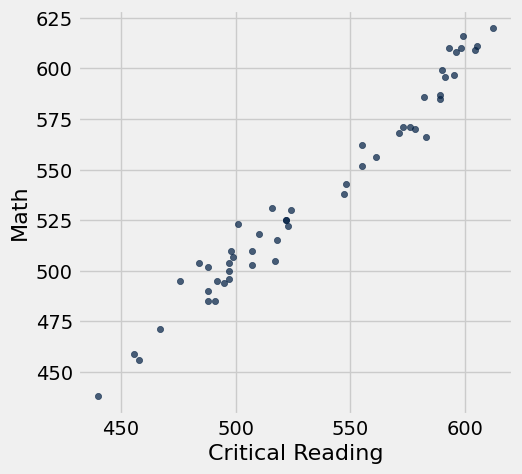

In [ ]:
sat2014.scatter('Critical Reading', 'Math')

In [ ]:
correlation(sat2014, 'Critical Reading', 'Math')

0.98475584110674341

그것은 매우 높은 상관관계입니다. 하지만 이것이 *학생들*의 수학 점수와 비판적 읽기 점수 사이의 관계 강도를 반영하지 않는다는 점에 유의하는 것이 중요합니다.

데이터는 각 주의 평균 점수로 구성됩니다. 하지만 주가 시험을 보는 것이 아니라 학생들이 봅니다. 테이블의 데이터는 각 주의 모든 학생을 해당 주의 두 변수 평균값에 있는 단일 점으로 묶어서 생성되었습니다. 그러나 학생마다 성적이 다르기 때문에 주의 모든 학생이 그 점에 있지는 않습니다. 각 주에 대해 하나가 아니라 각 학생에 대해 점을 찍으면 위 그림의 각 점 주위에 점들의 구름이 생길 것입니다. 전체적인 그림은 더 흐릿해질 것입니다. 학생들의 수학 점수와 비판적 읽기 점수 사이의 상관관계는 주 평균을 기반으로 계산된 값보다 *낮을* 것입니다.

집계 및 평균을 기반으로 한 상관관계를 *생태학적 상관관계(ecological correlations)*라고 하며 자주 보고됩니다. 방금 보았듯이 주의해서 해석해야 합니다.

## 진지한 것일까요, 농담일까요?

2012년, 권위 있는 뉴잉글랜드 의학 저널(New England Journal of Medicine)의 한 [논문](http://www.biostat.jhsph.edu/courses/bio621/misc/Chocolate%20consumption%20cognitive%20function%20and%20nobel%20laurates%20%28NEJM%29.pdf)은 한 국가 그룹의 초콜릿 소비량과 노벨상 사이의 관계를 조사했습니다. [사이언티픽 아메리칸(Scientific American)](http://blogs.scientificamerican.com/the-curious-wavefunction/chocolate-consumption-and-nobel-prizes-a-bizarre-juxtaposition-if-there-ever-was-one/)은 진지하게 반응한 반면
[다른 이들](http://www.reuters.com/article/2012/10/10/us-eat-chocolate-win-the-nobel-prize-idUSBRE8991MS20121010#vFdfFkbPVlilSjsB.97)은 좀 더 여유로웠습니다. 스스로 결정해 보십시오! 논문에서 제공된 다음 그래프는 여러분이 가서 살펴볼 동기를 부여할 것입니다.

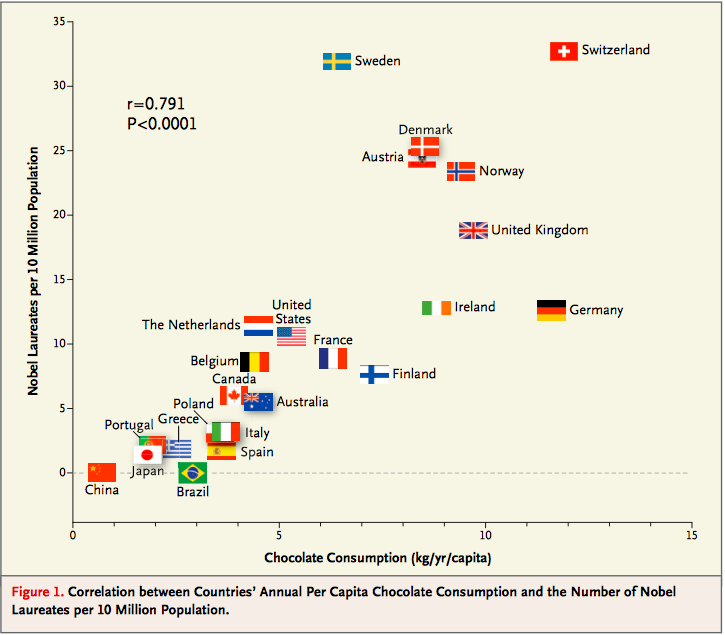

In [ ]:
from IPython.display import Image
Image("/content/gdrive/MyDrive/DataScience/images/chocoNobel.png")